In [ ]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('.'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

./test_cleaned.csv
./train_cleaned.csv
./recommandationsystem.ipynb
./.venv/pyvenv.cfg
./.venv/.gitignore
./.venv/bin/import_pb_to_tensorboard
./.venv/bin/pyftsubset
./.venv/bin/markdown_py
./.venv/bin/jupyter-run
./.venv/bin/Activate.ps1
./.venv/bin/python3
./.venv/bin/ttx
./.venv/bin/pip3.13
./.venv/bin/python
./.venv/bin/debugpy
./.venv/bin/pip3
./.venv/bin/ipython
./.venv/bin/activate.fish
./.venv/bin/fonttools
./.venv/bin/wheel
./.venv/bin/tf_upgrade_v2
./.venv/bin/f2py
./.venv/bin/ipython3
./.venv/bin/pip
./.venv/bin/markdown-it
./.venv/bin/jupyter-troubleshoot
./.venv/bin/pygmentize
./.venv/bin/jupyter-migrate
./.venv/bin/tensorboard
./.venv/bin/tflite_convert
./.venv/bin/activate
./.venv/bin/normalizer
./.venv/bin/numpy-config
./.venv/bin/saved_model_cli
./.venv/bin/toco
./.venv/bin/jupyter-kernelspec
./.venv/bin/jupyter-kernel
./.venv/bin/jupyter
./.venv/bin/debugpy-adapter
./.venv/bin/pyftmerge
./.venv/bin/python3.13
./.venv/bin/activate.csh
./.venv/lib/python3.13/site-packag

In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
users=pd.read_csv("./data/users.csv")
train_df=pd.read_csv("./data/train.csv")
test_df=pd.read_csv("./data/test.csv")
events_attendees=pd.read_csv("./data/event_attendees.csv.gz")
events = pd.read_csv('./data/events.csv.gz')



In [ ]:
users.head()

,user_id,locale,birthyear,gender,joinedAt,location,timezone
0,3197468391,id_ID,1993,male,2012-10-02T06:40:55.524Z,Medan Indonesia,480.0
1,3537982273,id_ID,1992,male,2012-09-29T18:03:12.111Z,Medan Indonesia,420.0
2,823183725,en_US,1975,male,2012-10-06T03:14:07.149Z,Stratford Ontario,-240.0
3,1872223848,en_US,1991,female,2012-11-04T08:59:43.783Z,Tehran Iran,210.0
4,3429017717,id_ID,1995,female,2012-09-10T16:06:53.132Z,NaN,420.0


In [ ]:
train_df.head()

,user,event,invited,timestamp,interested,not_interested
0,3044012,1918771225,0,2012-10-02 15:53:05.754000+00:00,0,0
1,3044012,1502284248,0,2012-10-02 15:53:05.754000+00:00,0,0
2,3044012,2529072432,0,2012-10-02 15:53:05.754000+00:00,1,0
3,3044012,3072478280,0,2012-10-02 15:53:05.754000+00:00,0,0
4,3044012,1390707377,0,2012-10-02 15:53:05.754000+00:00,0,0


In [ ]:
events.head()

,event_id,user_id,start_time,city,state,zip,country,lat,lng,c_1,...,c_92,c_93,c_94,c_95,c_96,c_97,c_98,c_99,c_100,c_other
0,684921758,3647864012,2012-10-31T00:00:00.001Z,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,1,0,0,0,0,0,0,0,9
1,244999119,3476440521,2012-11-03T00:00:00.001Z,NaN,NaN,NaN,NaN,NaN,NaN,2,...,0,0,0,0,0,0,0,0,0,7
2,3928440935,517514445,2012-11-05T00:00:00.001Z,NaN,NaN,NaN,NaN,NaN,NaN,0,...,0,0,0,0,0,0,0,0,0,12
3,2582345152,781585781,2012-10-30T00:00:00.001Z,NaN,NaN,NaN,NaN,NaN,NaN,1,...,0,0,0,0,0,0,0,0,0,8
4,1051165850,1016098580,2012-09-27T00:00:00.001Z,NaN,NaN,NaN,NaN,NaN,NaN,1,...,0,0,0,0,0,0,0,0,0,9


In [ ]:
events_attendees.head()

,event,yes,maybe,invited,no
0,1159822043,1975964455 252302513 4226086795 3805886383 142...,2733420590 517546982 1350834692 532087573 5831...,1723091036 3795873583 4109144917 3560622906 31...,3575574655 1077296663
1,686467261,2394228942 2686116898 1056558062 3792942231 41...,1498184352 645689144 3770076778 331335845 4239...,1788073374 733302094 1830571649 676508092 7081...,NaN
2,1186208412,NaN,3320380166 3810793697,1379121209 440668682,1728988561 2950720854
3,2621578336,NaN,NaN,NaN,NaN
4,855842686,2406118796 3550897984 294255260 1125817077 109...,2671721559 1761448345 2356975806 2666669465 10...,1518670705 880919237 2326414227 2673818347 332...,3500235232


In [ ]:
events_attendees['num_yes'] = events_attendees['yes'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
events_attendees['num_maybe'] = events_attendees['maybe'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
events_attendees['num_no'] = events_attendees['no'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)
events_attendees['num_invited'] = events_attendees['invited'].apply(lambda x: len(str(x).split()) if pd.notnull(x) else 0)

In [ ]:
event_attendees_df = events_attendees[['event', 'num_yes', 'num_maybe', 'num_no', 'num_invited']]
event_attendees_df.rename(columns={'event': 'event_id'}, inplace=True)

/var/folders/yq/jzqjtlgs7djgw3jkmmwv0gn80000gn/T/ipykernel_3472/1949455012.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  event_attendees_df.rename(columns={'event': 'event_id'}, inplace=True)


In [ ]:
# train.rename(columns={'user': 'user_id'}, inplace=True)

In [ ]:
# merged_df = pd.merge(train, users[['user_id', 'location']], on='user_id', how='left')


In [ ]:
# merged_df.rename(columns={'event': 'event_id'}, inplace=True)

In [ ]:
# merged_df = pd.merge(merged_df, events[['event_id', 'start_time', 'city', 'country']], on='event_id', how='left')

In [ ]:
# event_attendees_df.head()

In [ ]:
# merged_df = pd.merge(merged_df,event_attendees_df, on='event_id', how='left')

In [ ]:
# merged_df.head()

In [ ]:
# merged_df.info()

In [ ]:
# print(merged_df.isnull().sum())

In [ ]:
# merged_df.shape

In [ ]:
# import seaborn as sns
# sns.pairplot(merged_df)

In [ ]:

# missing_percentage = merged_df.isnull().mean() * 100
# print(missing_percentage)


In [ ]:
# merged_df = merged_df.dropna(subset=['location'])

In [ ]:
# merged_df['city'].fillna('Unknown', inplace=True)
# merged_df['country'].fillna('Unknown', inplace=True)

In [ ]:
# merged_df.isna().sum()

In [ ]:
# merged_df['location'].str.split()


In [ ]:
# merged_df['location'].tail(100) #format not good 

In [ ]:
# merged_df['location'].value_counts()


In [ ]:
# import pandas as pd
# import re
# # Function to extract user_city and user_country
# def extract_city_country(location):
#     #  Remove the numbers in the string
#     cleaned_location = re.sub(r'\d+', '', location)
    
#     # Split the words
#     words = cleaned_location.split()
    
#     # Handle the cases according to the number of words after removing the numbers
#     if len(words) > 2:
#         # Concatenate the first two words for user_city and the rest for user_country
#         user_city = ' '.join(words[:2])
#         user_country = ' '.join(words[2:])
#     elif len(words) == 2:
#         # If two words, first for user_city and second for user_country
#         user_city = words[0]
#         user_country = words[1]
#     else:
#         # Case of less than two words (incomplete)
#         user_city = words[0] if words else 'Unknown'
#         user_country = 'Unknown'
    
#     return pd.Series([user_city, user_country])



    

In [ ]:
# # Calculate the function to the column 'location'
# merged_df[['user_city', 'user_country']] = merged_df['location'].apply(extract_city_country)

# # Display the result
# print(merged_df[['location', 'user_city', 'user_country']])

In [ ]:
# merged_df.tail(100)

In [ ]:
# merged_df['timestamp'] = pd.to_datetime(merged_df['timestamp'], errors='coerce')
# merged_df['start_time'] = pd.to_datetime(merged_df['start_time'], errors='coerce')

In [ ]:
# merged_df['user_time'] =merged_df['timestamp'].dt.strftime('%Y/%m/%d %H:%M:%S')
# merged_df['event_time'] = merged_df['start_time'].dt.strftime('%Y/%m/%d %H:%M:%S')

In [ ]:
# merged_df.info()

In [ ]:
# merged_df.drop("location",axis=1,inplace=True)
# merged_df.drop("timestamp",axis=1,inplace=True)
# merged_df.drop("start_time",axis=1,inplace=True)

In [ ]:
# merged_df.head()

In [ ]:
# merged_df.shape

In [ ]:
# merged_df['user_id'].nunique()


In [ ]:
# merged_df[merged_df['user_id'] == 3044012]

In [ ]:
# merged_df['user_time'] = pd.to_datetime(merged_df['user_time'], errors='coerce')
# merged_df['event_time'] = pd.to_datetime(merged_df['event_time'], errors='coerce')

In [ ]:
# from datetime import datetime

# users['birthyear']=pd.to_datetime(users['birthyear'], errors='coerce')

In [ ]:
# # Step 1: Merge merged_df with users on user_id
# merged_df = merged_df.merge(users[['user_id', 'birthyear']], on='user_id', how='left')

In [ ]:
# # Step 2: Calculate the age of the user
# current_year = datetime.now().year
# merged_df['user_old'] = current_year - merged_df['birthyear'].dt.year

# # Step 3: Drop the birthyear column if you don't need it
# merged_df.drop(columns=['birthyear'], inplace=True)

In [ ]:
# # Calculate the time difference between the event time and the user time
# merged_df['delai']=merged_df['event_time']-merged_df['user_time']

In [ ]:
# merged_df.head()

In [ ]:
# merged_df.dropna(subset=['user_time', 'user_old', 'delai'], inplace=True)

In [ ]:
# merged_df.isna().sum()

In [ ]:
# merged_df.info()

In [ ]:
# merged_df['user_city'].nunique()

In [ ]:
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.base import BaseEstimator, TransformerMixin

class PreprocessingPipeline(BaseEstimator, TransformerMixin):
    def __init__(self, train=True):
        self.train = train  # Indicate if we are processing a training or test file
    
    def fit(self, X, y=None):
        return self  # No learning in the pipeline

    def transform(self, data):
        # Load the necessary external files
        users=pd.read_csv("./data/users.csv")
        events_attendees=pd.read_csv("./data/event_attendees.csv.gz")
        events = pd.read_csv('./data/events.csv.gz')



        # Merge the datasets
        data.rename(columns={'user': 'user_id'}, inplace=True)
        data = pd.merge(data, users[['user_id', 'location', 'birthyear']], on='user_id', how='left')
        data.rename(columns={'event': 'event_id'}, inplace=True)
        data = pd.merge(data, events[['event_id', 'start_time', 'city', 'country']], on='event_id', how='left')
        data = pd.merge(data, event_attendees_df, on='event_id', how='left')

        # Fill the missing values
        data.dropna(subset=['location'], inplace=True)
        data['city'].fillna('Unknown', inplace=True)
        data['country'].fillna('Unknown', inplace=True)

        # Extract user_city and user_country from location
        data[['user_city', 'user_country']] = data['location'].apply(self.extract_city_country)

        # Convert the timestamps to datetime
        data['timestamp'] = pd.to_datetime(data['timestamp'], errors='coerce')
        data['start_time'] = pd.to_datetime(data['start_time'], errors='coerce')
        data['user_time'] = data['timestamp'].dt.strftime('%Y/%m/%d %H:%M:%S')
        data['event_time'] = data['start_time'].dt.strftime('%Y/%m/%d %H:%M:%S')

        # Drop the location column
        data.drop(columns=['location', 'timestamp', 'start_time'], inplace=True)

        # Convert to datetime
        data['user_time'] = pd.to_datetime(data['user_time'], errors='coerce')
        data['event_time'] = pd.to_datetime(data['event_time'], errors='coerce')

        # Calculate the age of the user
        data['birthyear'] = pd.to_datetime(data['birthyear'], errors='coerce')
        current_year = datetime.now().year
        data['user_old'] = current_year - data['birthyear'].dt.year

        # Drop the birthyear column
        data.drop(columns=['birthyear'], inplace=True)

        # Calculate the time difference between the event and the interaction
        data['delai'] = data['event_time'] - data['user_time']

        # Drop the missing values
        data.dropna(subset=['user_time', 'user_old', 'delai'], inplace=True)

        return data

    @staticmethod
    def extract_city_country(location):
        """ Function to extract user_city and user_country """
        cleaned_location = re.sub(r'\d+', '', location)
        words = cleaned_location.split()
        if len(words) > 2:
            user_city = ' '.join(words[:2])
            user_country = ' '.join(words[2:])
        elif len(words) == 2:
            user_city = words[0]
            user_country = words[1]
        else:
            user_city = words[0] if words else 'Unknown'
            user_country = 'Unknown'
        return pd.Series([user_city, user_country])



In [ ]:
# Apply the preprocessing pipeline
preprocessor = PreprocessingPipeline()

# Transform the training and test data
train_cleaned = preprocessor.fit_transform(train_df)
test_cleaned = preprocessor.transform(test_df)  # No need to `fit` for the test

# Save the cleaned files
train_cleaned.to_csv("train_cleaned.csv", index=False)
test_cleaned.to_csv("test_cleaned.csv", index=False)

print("Preprocessing completed!")


/var/folders/yq/jzqjtlgs7djgw3jkmmwv0gn80000gn/T/ipykernel_3472/1867395380.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['city'].fillna('Unknown', inplace=True)
/var/folders/yq/jzqjtlgs7djgw3jkmmwv0gn80000gn/T/ipykernel_3472/1867395380.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

Preprocessing completed!


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
from tensorflow.keras.models import Model
from sklearn.preprocessing import LabelEncoder
def preprocess_data(df, label_encoders=None, is_train=True):
    df = df.copy()
    
    if is_train:
        label_encoders = {}
        for col in ['city', 'country', 'user_city', 'user_country']:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col])
            label_encoders[col] = le
    else:
        for col in ['city', 'country', 'user_city', 'user_country']:
            # Check if the column contains unknown values
            df[col] = df[col].apply(lambda x: x if x in label_encoders[col].classes_ else 'unknown')
            le_classes = np.append(label_encoders[col].classes_, 'unknown')
            label_encoders[col].classes_ = le_classes
            df[col] = label_encoders[col].transform(df[col])
    
    X_num = df[['user_id', 'event_id', 'invited', 'num_yes', 'num_maybe', 'num_no', 
                'num_invited', 'user_old']].copy()

    X_num['user_time'] = df['user_time'].astype('int64') // 10**9
    X_num['event_time'] = df['event_time'].astype('int64') // 10**9

    X_num['delai'] = df['delai'].dt.total_seconds()

    X_cat = df[['city', 'country', 'user_city', 'user_country']]
    
    y = df['interested'] if is_train else None

    return X_cat, X_num, y, label_encoders if is_train else None


# Preprocessing on train_cleaned
X_cat_train, X_num_train, y_train, label_encoders = preprocess_data(train_cleaned, is_train=True)

# Preprocessing on test_cleaned using the same encoders
X_cat_test, X_num_test, _, _ = preprocess_data(test_cleaned, label_encoders, is_train=False)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define the embedding dimensions
embedding_dim = 40

# Define the inputs
input_city = Input(shape=(1,), name='input_city')
input_country = Input(shape=(1,), name='input_country')
input_user_city = Input(shape=(1,), name='input_user_city')
input_user_country = Input(shape=(1,), name='input_user_country')

# Embedding layers
embedding_city = Embedding(input_dim=len(label_encoders['city'].classes_), output_dim=embedding_dim, name='embedding_city')(input_city)
embedding_country = Embedding(input_dim=len(label_encoders['country'].classes_), output_dim=embedding_dim, name='embedding_country')(input_country)
embedding_user_city = Embedding(input_dim=len(label_encoders['user_city'].classes_), output_dim=embedding_dim, name='embedding_user_city')(input_user_city)
embedding_user_country = Embedding(input_dim=len(label_encoders['user_country'].classes_), output_dim=embedding_dim, name='embedding_user_country')(input_user_country)

# Flatten the embeddings
flatten_city = Flatten()(embedding_city)
flatten_country = Flatten()(embedding_country)
flatten_user_city = Flatten()(embedding_user_city)
flatten_user_country = Flatten()(embedding_user_country)

# Input for the numeric features
input_numeric = Input(shape=(X_num_train.shape[1],), name='input_numeric')

# Concatenation of the embeddings and the numeric features
merged = Concatenate()([flatten_city, flatten_country, flatten_user_city, flatten_user_country, input_numeric])

# Hidden layers of the model
x = Dense(128, activation='relu')(merged)
x = Dense(64, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)  # Binary prediction

# Define the model
model = Model(inputs=[input_city, input_country, input_user_city, input_user_country, input_numeric], outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


from sklearn.model_selection import train_test_split

X_cat_train, X_cat_valid, X_num_train, X_num_valid, y_train, y_valid = train_test_split(
    X_cat_train, X_num_train, y_train, test_size=0.2, random_state=42
)
early_stopping = EarlyStopping(
    monitor='val_loss',  # Watch the validation loss
    patience=6,          # Number of epochs without improvement before stopping
    restore_best_weights=True,  # Restore the best model weights
    verbose=1
)
# Training the model on train_cleaned
history = model.fit(
    x=[X_cat_train['city'], X_cat_train['country'], X_cat_train['user_city'], X_cat_train['user_country'], X_num_train],
    y=y_train,
    epochs=100,
    batch_size=64,
    validation_data=(
        [X_cat_valid['city'], X_cat_valid['country'], X_cat_valid['user_city'], X_cat_valid['user_country'], X_num_valid], 
        y_valid
    ),
    callbacks=[early_stopping]  # Add the callback for early stopping

)



Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_city          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_country       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_user_city     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_user_country  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_city      │ (None, 1, 40)     │     33,080 │ input_city[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_country   │ (None, 1, 40)     │      3,040 │ input_country[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_user_city │ (None, 1, 40)     │     14,480 │ input_user_city[… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_user_cou… │ (None, 1, 40)     │      5,160 │ input_user_count… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 40)        │          0 │ embedding_city[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 40)        │          0 │ embedding_countr… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 40)        │          0 │ embedding_user_c… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 40)        │          0 │ embedding_user_c… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_numeric       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 171)       │          0 │ flatten_8[0][0],  │
│ (Concatenate)       │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ flatten_10[0][0], │
│                     │                   │            │ flatten_11[0][0], │
│                     │                   │            │ input_numeric[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │     22,016 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 86,097 (336.32 KB)

 Trainable params: 86,097 (336.32 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5968 - loss: 4221516.0000 - val_accuracy: 0.5539 - val_loss: 1604677.1250
Epoch 2/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6127 - loss: 3269094.7500 - val_accuracy: 0.7070 - val_loss: 2897707.2500
Epoch 3/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6106 - loss: 3792817.5000 - val_accuracy: 0.6838 - val_loss: 1239606.5000
Epoch 4/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6075 - loss: 2833558.5000 - val_accuracy: 0.7089 - val_loss: 1758955.3750
Epoch 5/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6045 - loss: 3251363.5000 - val_accuracy: 0.4718 - val_loss: 5474464.5000
Epoch 6/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6201 - loss: 2066769.3750 - val_accuracy: 0.7114 - val_loss: 2198168.0000
Epoch 7/100
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6027 - loss: 2122502.7500 - val_accuracy: 0.7114 - val_loss: 3036132.2500
Epoch 8/100
1

In [ ]:
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Embedding, Flatten, Concatenate, Dense
# from tensorflow.keras.models import Model
# from sklearn.preprocessing import LabelEncoder
# from sklearn.model_selection import train_test_split



# # Encode the categorical columns
# label_encoders = {}
# for col in ['city', 'country', 'user_city', 'user_country']:
#     le = LabelEncoder()
#     merged_df[col] = le.fit_transform(merged_df[col])
#     label_encoders[col] = le  # Save the encoders for later

# # Numeric features
# X_num = merged_df[['user_id', 'event_id', 'invited', 'num_yes', 'num_maybe', 'num_no', 
#                    'num_invited', 'user_old']].copy()

# # Transform the datetime columns to timestamps
# X_num['user_time'] = merged_df['user_time'].astype('int64') // 10**9
# X_num['event_time'] = merged_df['event_time'].astype('int64') // 10**9

# # Transformation of timedelta to seconds
# X_num['delai'] = merged_df['delai'].dt.total_seconds()

# # Target
# y = merged_df['interested']

# # Separating the categorical and numeric data
# X_cat = merged_df[['city', 'country', 'user_city', 'user_country']]

# # Separating the train/test data
# X_cat_train, X_cat_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
#     X_cat, X_num, y, test_size=0.2, random_state=42
# )

# # Define the embedding dimensions
# embedding_dim = 40

# # Define the inputs
# input_city = Input(shape=(1,), name='input_city')
# input_country = Input(shape=(1,), name='input_country')
# input_user_city = Input(shape=(1,), name='input_user_city')
# input_user_country = Input(shape=(1,), name='input_user_country')

# # Embedding layers
# embedding_city = Embedding(input_dim=max(2, len(label_encoders['city'].classes_)), output_dim=embedding_dim, name='embedding_city')(input_city)
# embedding_country = Embedding(input_dim=max(2, len(label_encoders['country'].classes_)), output_dim=embedding_dim, name='embedding_country')(input_country)
# embedding_user_city = Embedding(input_dim=max(2, len(label_encoders['user_city'].classes_)), output_dim=embedding_dim, name='embedding_user_city')(input_user_city)
# embedding_user_country = Embedding(input_dim=max(2, len(label_encoders['user_country'].classes_)), output_dim=embedding_dim, name='embedding_user_country')(input_user_country)

# # Flatten the embeddings
# flatten_city = Flatten()(embedding_city)
# flatten_country = Flatten()(embedding_country)
# flatten_user_city = Flatten()(embedding_user_city)
# flatten_user_country = Flatten()(embedding_user_country)

# # Input for the numeric features
# input_numeric = Input(shape=(X_num_train.shape[1],), name='input_numeric')

# # Concatenation of the embeddings and the numeric features
# merged = Concatenate()([flatten_city, flatten_country, flatten_user_city, flatten_user_country, input_numeric])

# # Hidden layers of the model
# x = Dense(128, activation='relu')(merged)
# x = Dense(64, activation='relu')(x)
# output = Dense(1, activation='sigmoid')(x)  # Binary prediction

# # Define the model
# model = Model(inputs=[input_city, input_country, input_user_city, input_user_country, input_numeric], outputs=output)
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# model.summary()

# # Training the model
# history = model.fit(
#     x=[X_cat_train['city'], X_cat_train['country'], X_cat_train['user_city'], X_cat_train['user_country'], X_num_train],
#     y=y_train,
#     validation_data=([X_cat_test['city'], X_cat_test['country'], X_cat_test['user_city'], X_cat_test['user_country'], X_num_test], y_test),
#     epochs=40,
#     batch_size=32
# )


In [ ]:
print(X_cat_train.columns)


Index(['city', 'country', 'user_city', 'user_country'], dtype='object')


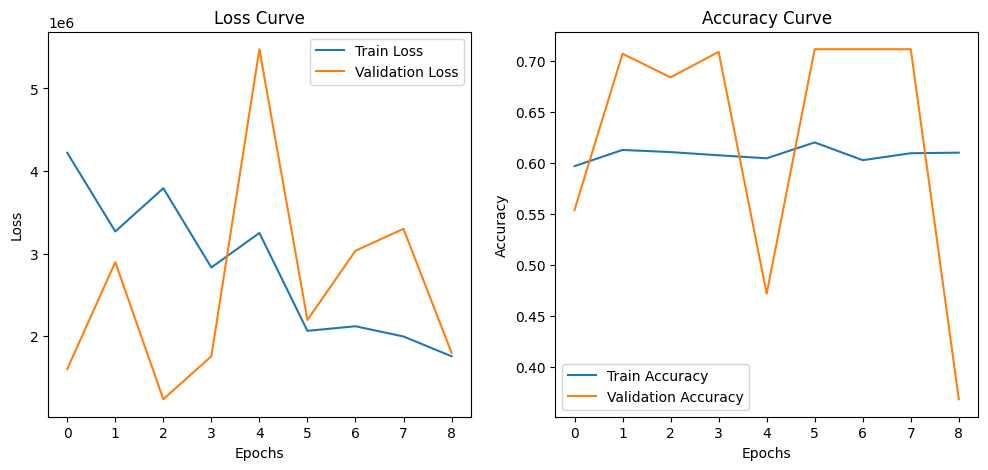

In [ ]:
import matplotlib.pyplot as plt

# Get the training history
history_dict = history.history

# Plot the loss curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_dict['loss'], label='Train Loss')
plt.plot(history_dict['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss Curve')
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_dict['accuracy'], label='Train Accuracy')
plt.plot(history_dict['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

plt.show()


In [ ]:
X_cat_test.columns

Index(['city', 'country', 'user_city', 'user_country'], dtype='object')

In [ ]:
# Predict on the test set
y_pred = model.predict([
    X_cat_test['city'], 
    X_cat_test['country'], 
    X_cat_test['user_city'], 
    X_cat_test['user_country'], 
    X_num_test
])

# Display the first predictions
print(y_pred[:30])  # Display the first 10 predictions


284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 839us/step
[[0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]
 [0.]]


In [ ]:
# Evaluation of the model on the validation data
val_loss, val_accuracy = model.evaluate(
    [X_cat_valid['city'], X_cat_valid['country'], X_cat_valid['user_city'], X_cat_valid['user_country'], X_num_valid], 
    y_valid
)

print(f"Loss on validation: {val_loss}")
print(f"Accuracy on validation: {val_accuracy}")


85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - accuracy: 0.6838 - loss: 1239606.8750
Loss on validation: 1239606.875
Accuracy on validation: 0.6838424801826477


In [ ]:
# Do predictions on the validation data
y_pred_proba = model.predict([X_cat_valid['city'], X_cat_valid['country'], X_cat_valid['user_city'], X_cat_valid['user_country'], X_num_valid])

# Convert the probabilities to classes
y_pred_classes = (y_pred_proba > 0.5).astype(int)

# Display the first predictions with the true values
for i in range(50):
    print(f"True: {y_valid.iloc[i]}, Predicted: {y_pred_classes[i]}")


85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 569us/step
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 1, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 1, Predicted: [0]
True: 1, Predicted: [0]
True: 1, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 1, Predicted: [0]
True: 0, Predicted: [1]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 1, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 1, Predicted: [0]
True: 0, Predicted: [0]
True: 1, Predicted: [0]
True: 1, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]
True: 0, Predicted: [0]